# Script to test trained Collision Avoidance Maneuver (CAM) policy



In [1]:

import os
import sys
import random 
import json 

import numpy as np
import pandas as pd
import torch as T

from leo_gym.utils.utils import seed_all, create_dir
from pathlib import Path


In [2]:
from leo_gym.gyms.cam_gym import CamEnv, CamEnvConfig
# from train_cam_hppo_cfg import env_cfg


flag = 0
SEED = np.random.randint(0,100000)
print(SEED)
# SEED = 62008
# SEED = 55814
# SEED = 49497
# SEED = 84606

# 80366
# 62266
# 33962
# 37950
# SEED = 57761
# 63289

env_cfg = "/home/nektaf/workspace_optacom/libs/leo_gym/notebooks/C3_Collision_Avoidance_Maneuvers_SMDP/trained_policy_net_cfg/env_cfg.json"
def make_env():
    return CamEnv(env_cfg, seed=SEED)

num_envs = 1
env = make_env()
obs = env.reset()


86217


In [3]:

from leo_gym.rl_algorithms.h_ppo.h_ppo_agent import Agent


policy_file_path = "/home/nektaf/workspace_optacom/libs/leo_gym/notebooks/C3_Collision_Avoidance_Maneuvers_SMDP/trained_policy_net_cfg/policynet.pth"
critic_file_path = "/home/nektaf/workspace_optacom/libs/leo_gym/notebooks/C3_Collision_Avoidance_Maneuvers_SMDP/trained_policy_net_cfg/valuenet.pth"
ppo_config = "/home/nektaf/workspace_optacom/libs/leo_gym/notebooks/C3_Collision_Avoidance_Maneuvers_SMDP/trained_policy_net_cfg/ppo_cfg.json"

ppo = Agent(
    env_obs=env.observation_space,
    env_actions=env.action_space,
    ppo_cfg=ppo_config,
    train=False,
    policy_file_path=policy_file_path,
    critic_file_path=critic_file_path,
    device='cpu'
)


In [4]:
truncated = False 
terminated = False
state = env.reset()[0]

rewards =[]
costs= []
simulation_times = []

# env.reset()

for i in range(100):
    
    action_dis, action_cont, prob_dis, prob_cont, val = ppo.choose_action(state, deterministic=True)
            
    action = {
            "discrete": action_dis,                     
            "continuous": action_cont,
        }
    
    next_state, reward, terminated, truncated, info = env.step(action)

    state = next_state
    DebrisSwarm_1 = env.DebrisSwarm_1
    rewards.append(reward)
    costs.append(info["cost"])
    print(action)
    simulation_times.append(info["n"])

    if terminated: 
        break
    if truncated:
        break
    
print(i)

{'discrete': array(1), 'continuous': array([0.94752663, 0.5665243 ], dtype=float32)}
{'discrete': array(1), 'continuous': array([0.9383427, 0.8225138], dtype=float32)}
{'discrete': array(1), 'continuous': array([0.9044718, 0.8966982], dtype=float32)}
{'discrete': array(1), 'continuous': array([0.9635096 , 0.73449665], dtype=float32)}
{'discrete': array(0), 'continuous': array([0.970717, 0.813117], dtype=float32)}
{'discrete': array(0), 'continuous': array([0.97260284, 0.8678734 ], dtype=float32)}
{'discrete': array(0), 'continuous': array([0.9621968 , 0.90780574], dtype=float32)}
{'discrete': array(2), 'continuous': array([0.8895203, 0.9258419], dtype=float32)}
{'discrete': array(2), 'continuous': array([0.58658826, 0.88348407], dtype=float32)}
{'discrete': array(2), 'continuous': array([-0.6802234 ,  0.30139494], dtype=float32)}
{'discrete': array(2), 'continuous': array([-0.4994432 ,  0.09474262], dtype=float32)}
{'discrete': array(2), 'continuous': array([-0.46221593, -0.37985983], 

In [5]:
sum(rewards)

982.648192062931

In [6]:
env.plot_states_interactive()

/home/nektaf/workspace_optacom/libs/leo_gym/src/leo_gym/gyms/cam_gym.py:417: RuntimeWarning:

divide by zero encountered in log10



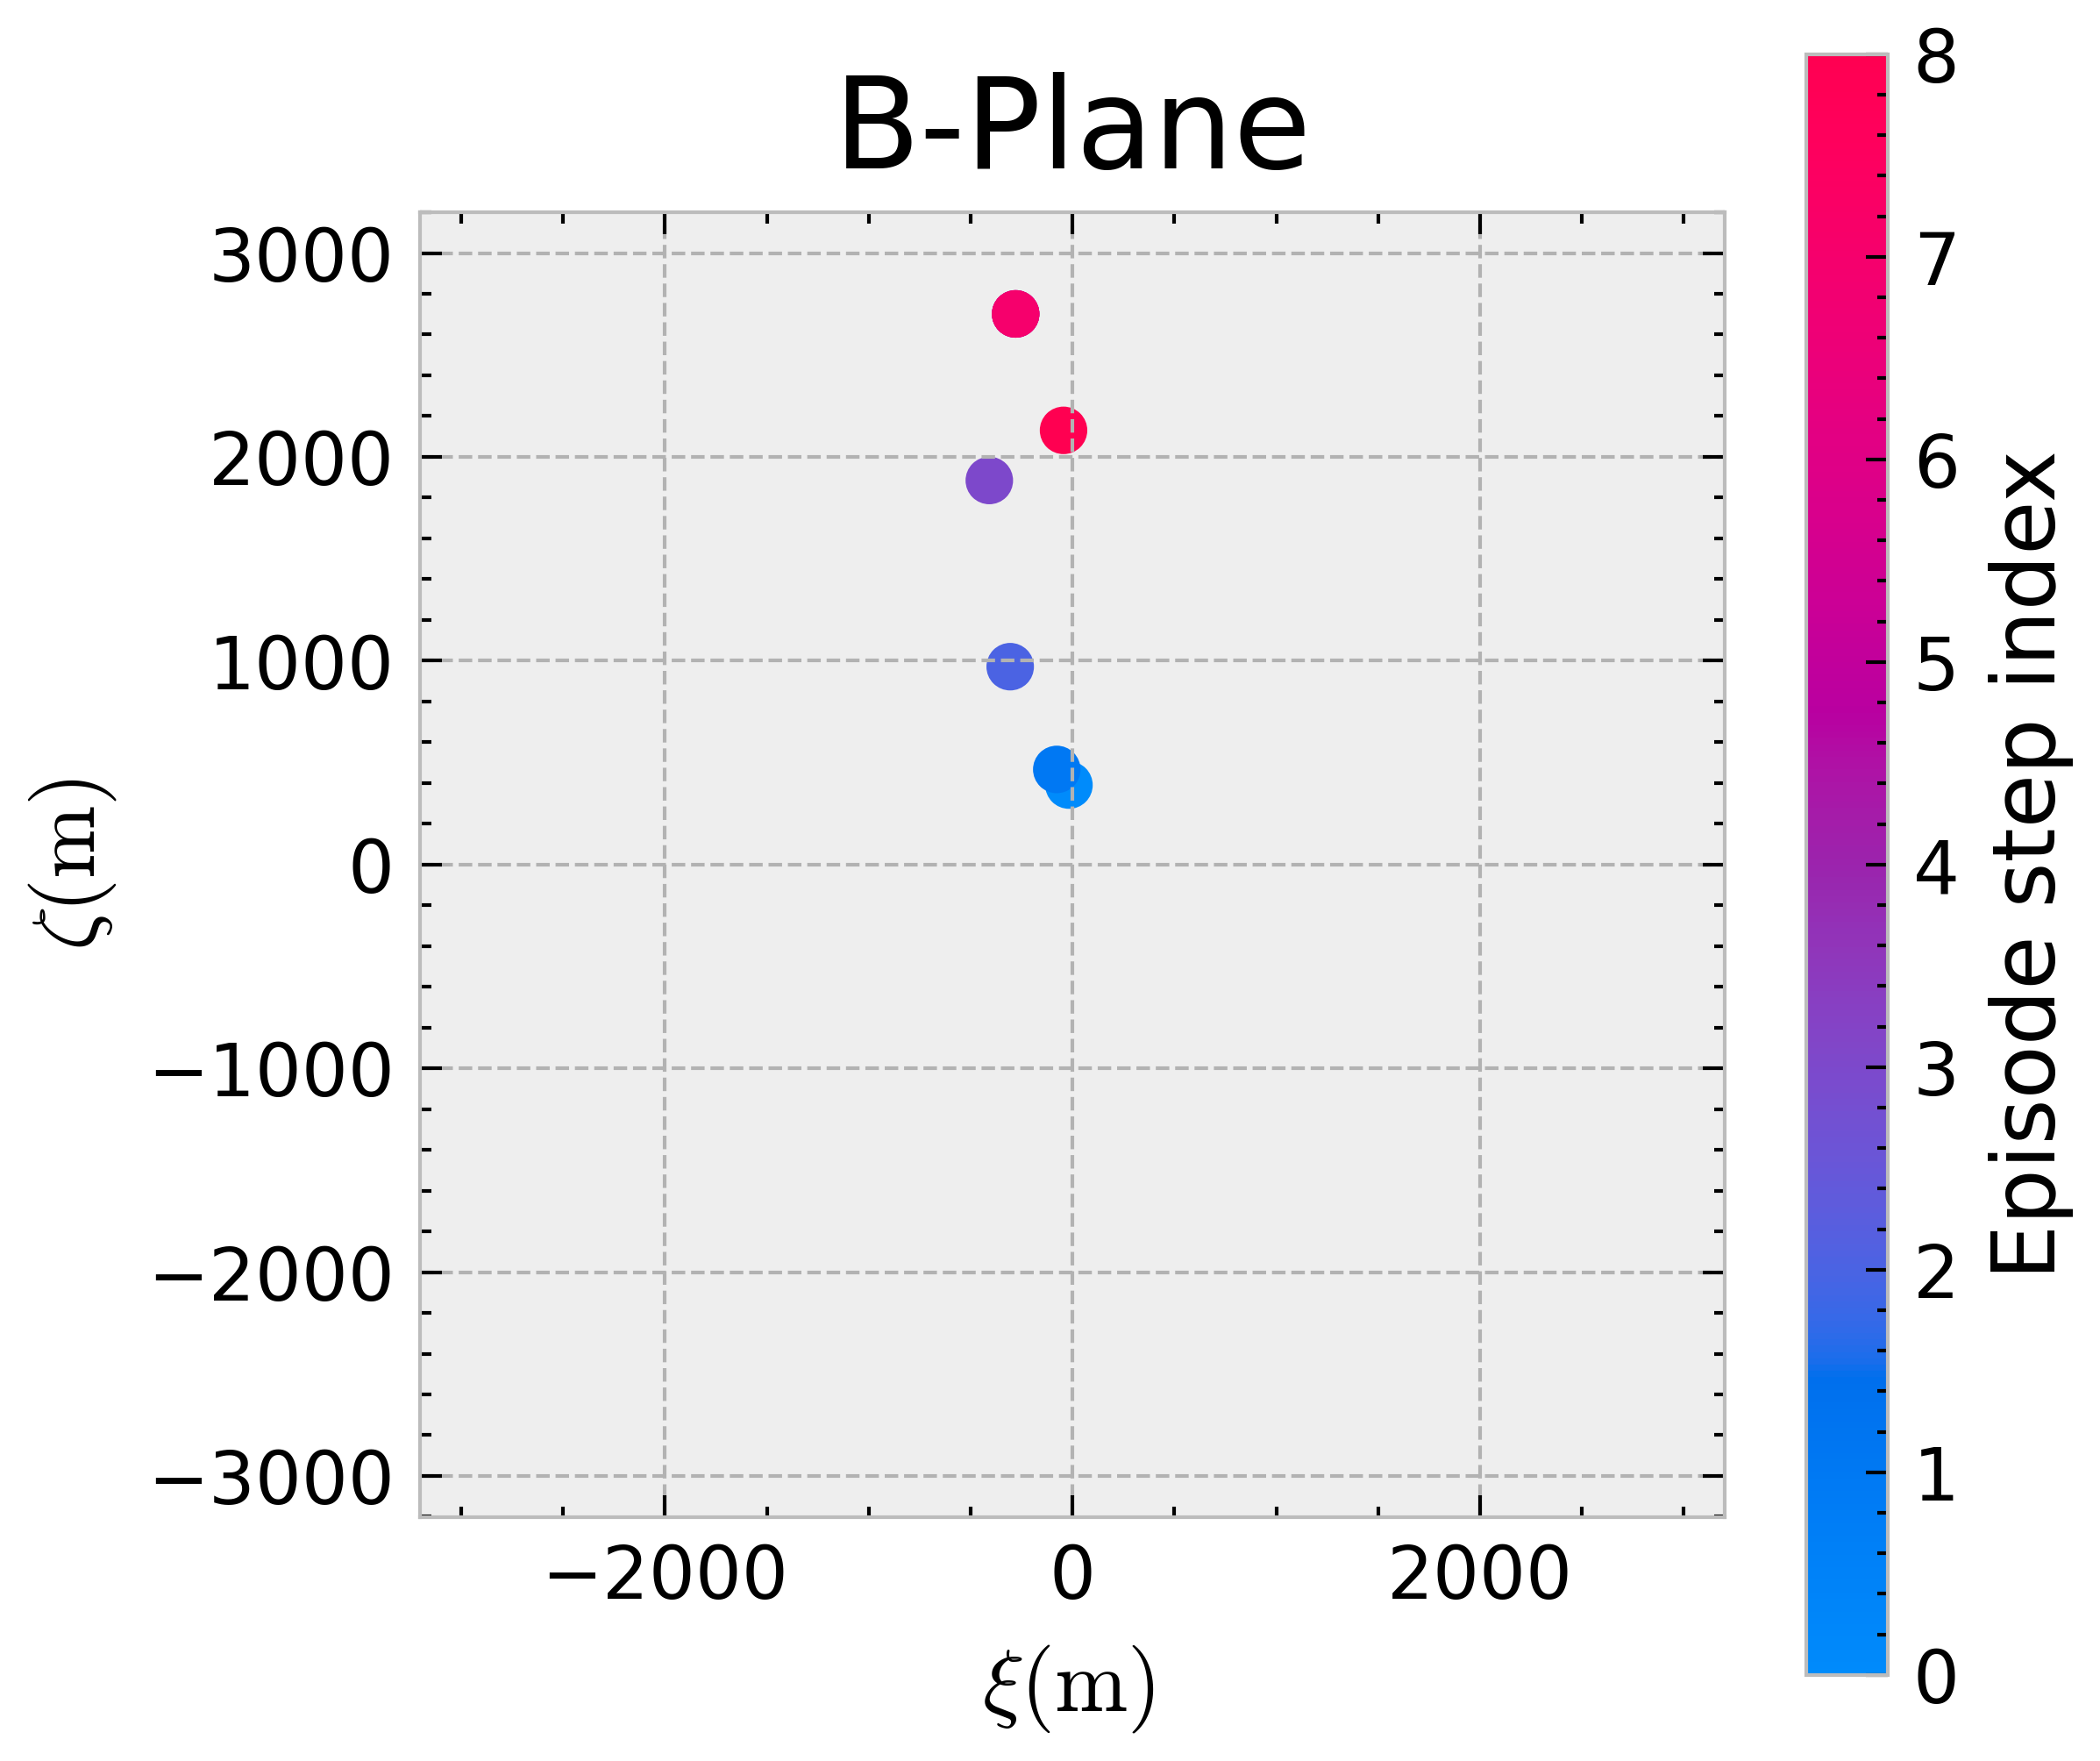

In [7]:
DebrisSwarm_1.plot_projected_position_bplane()

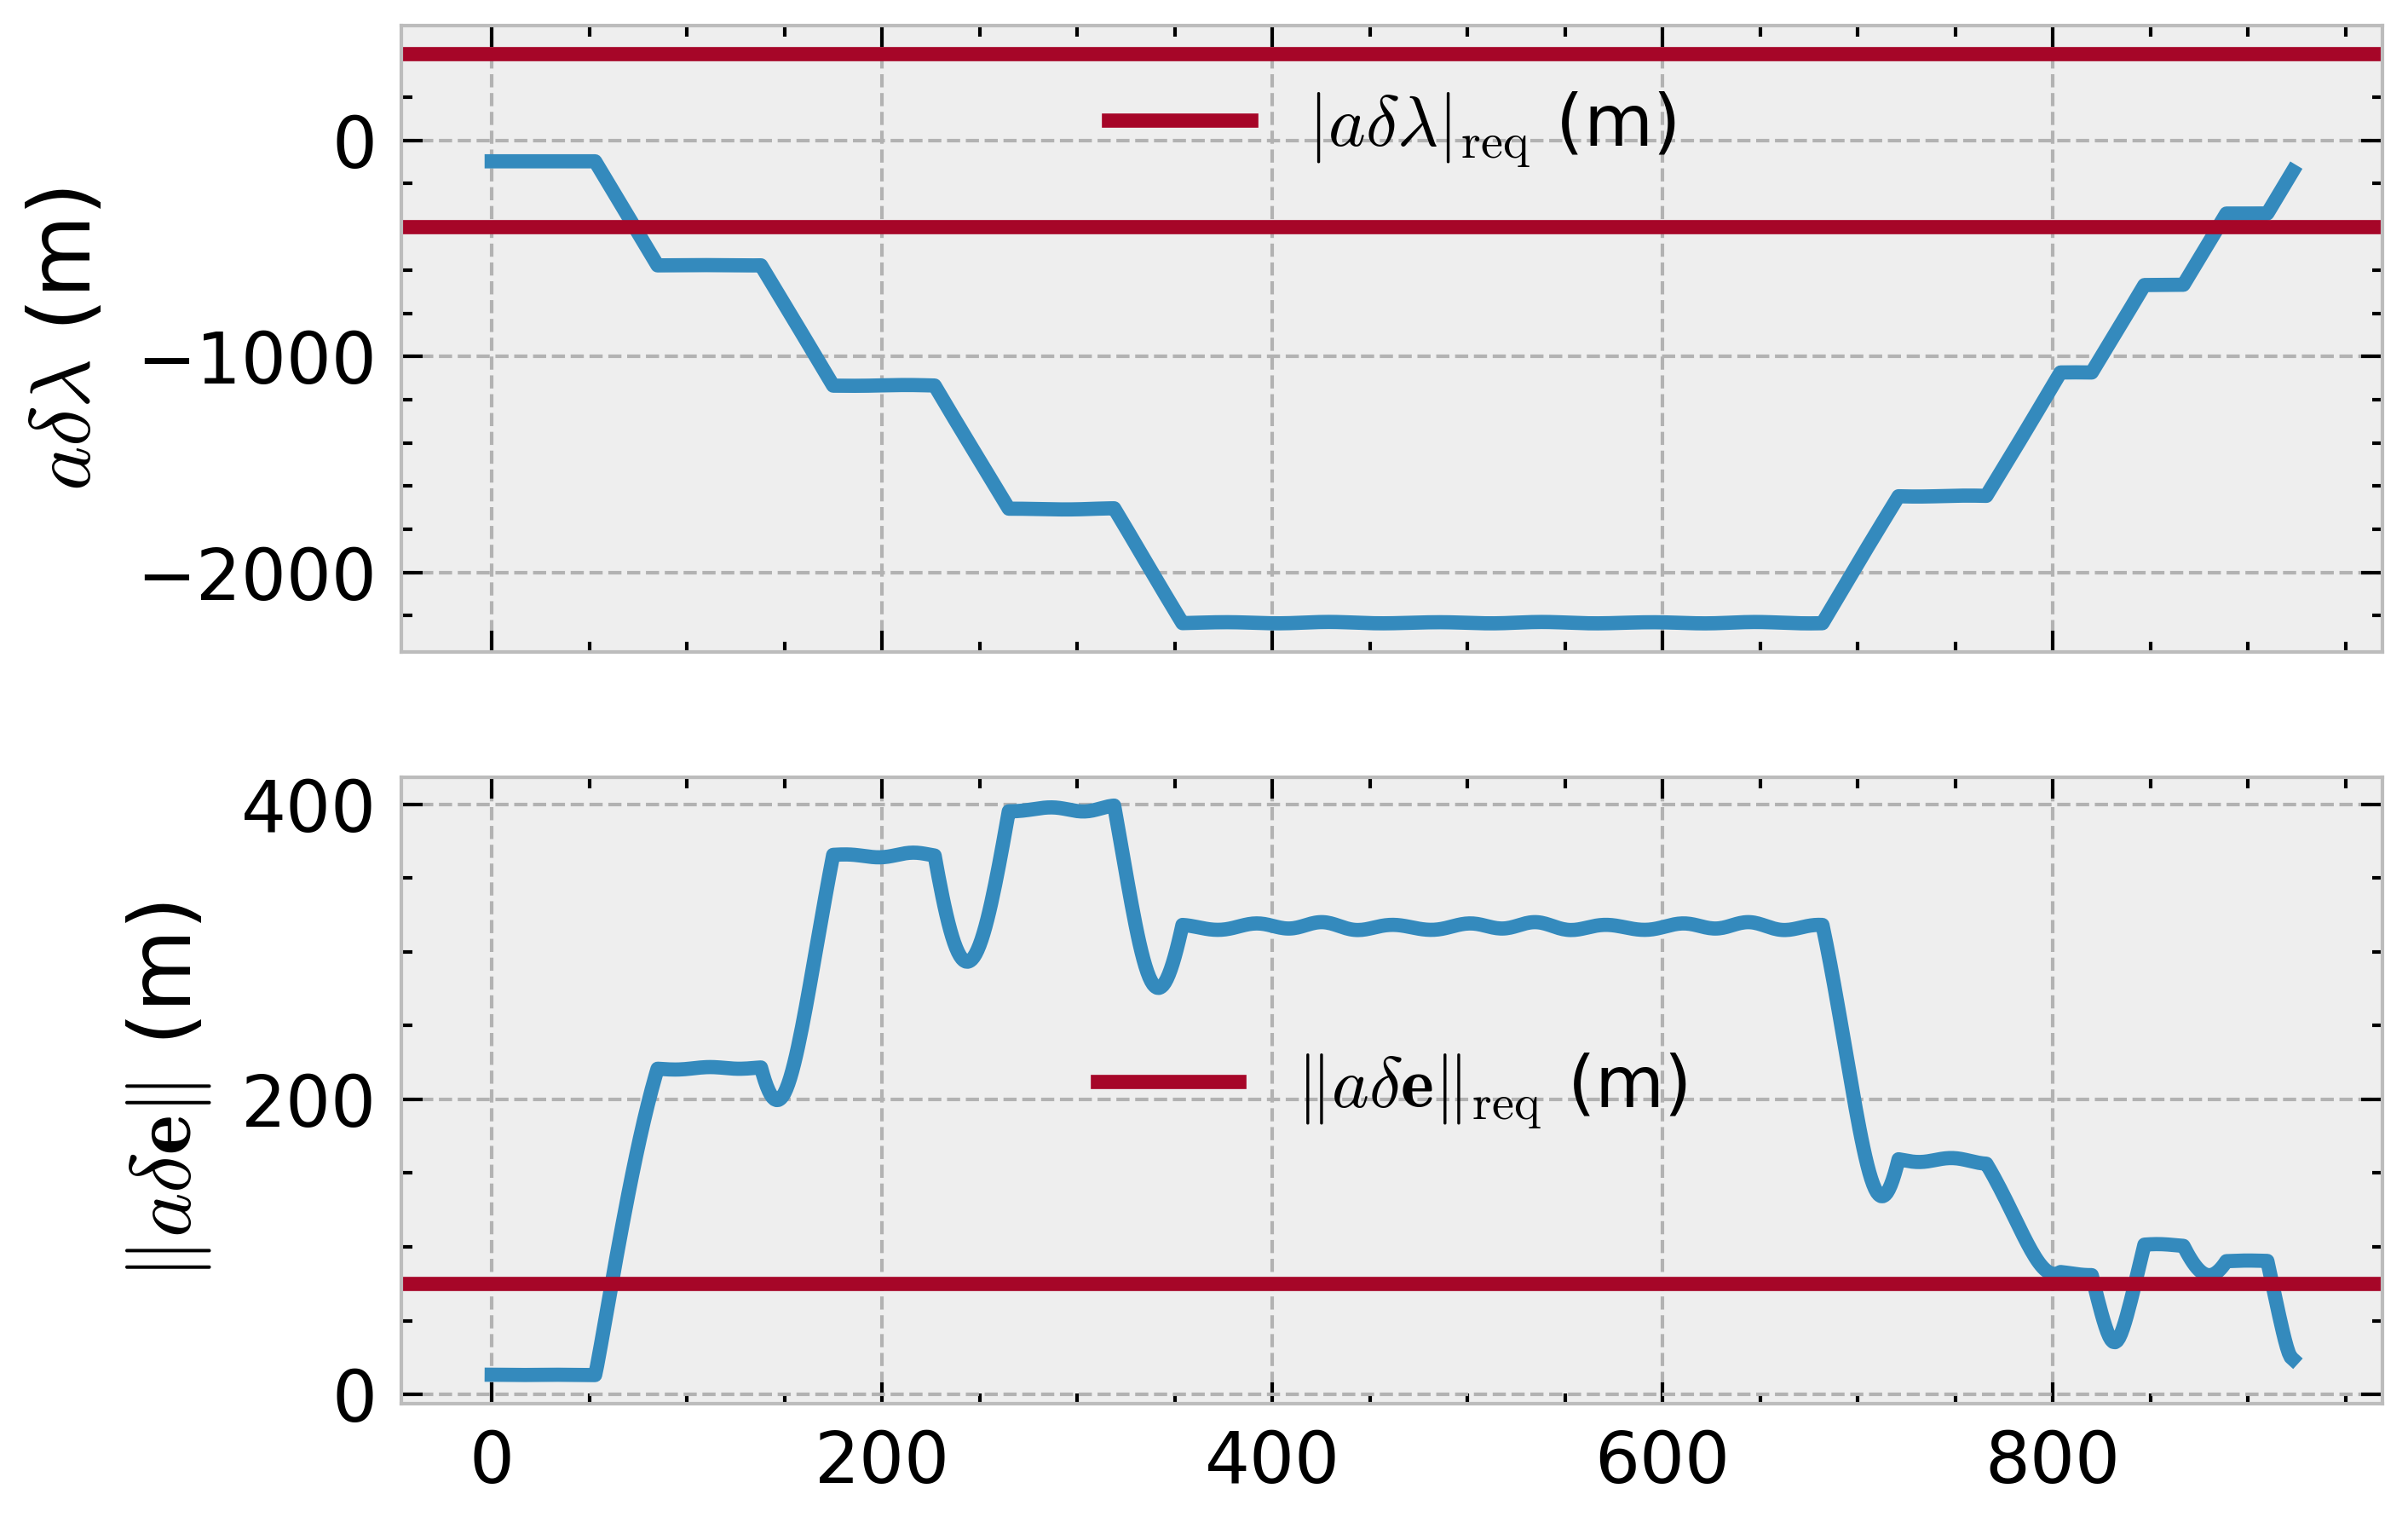

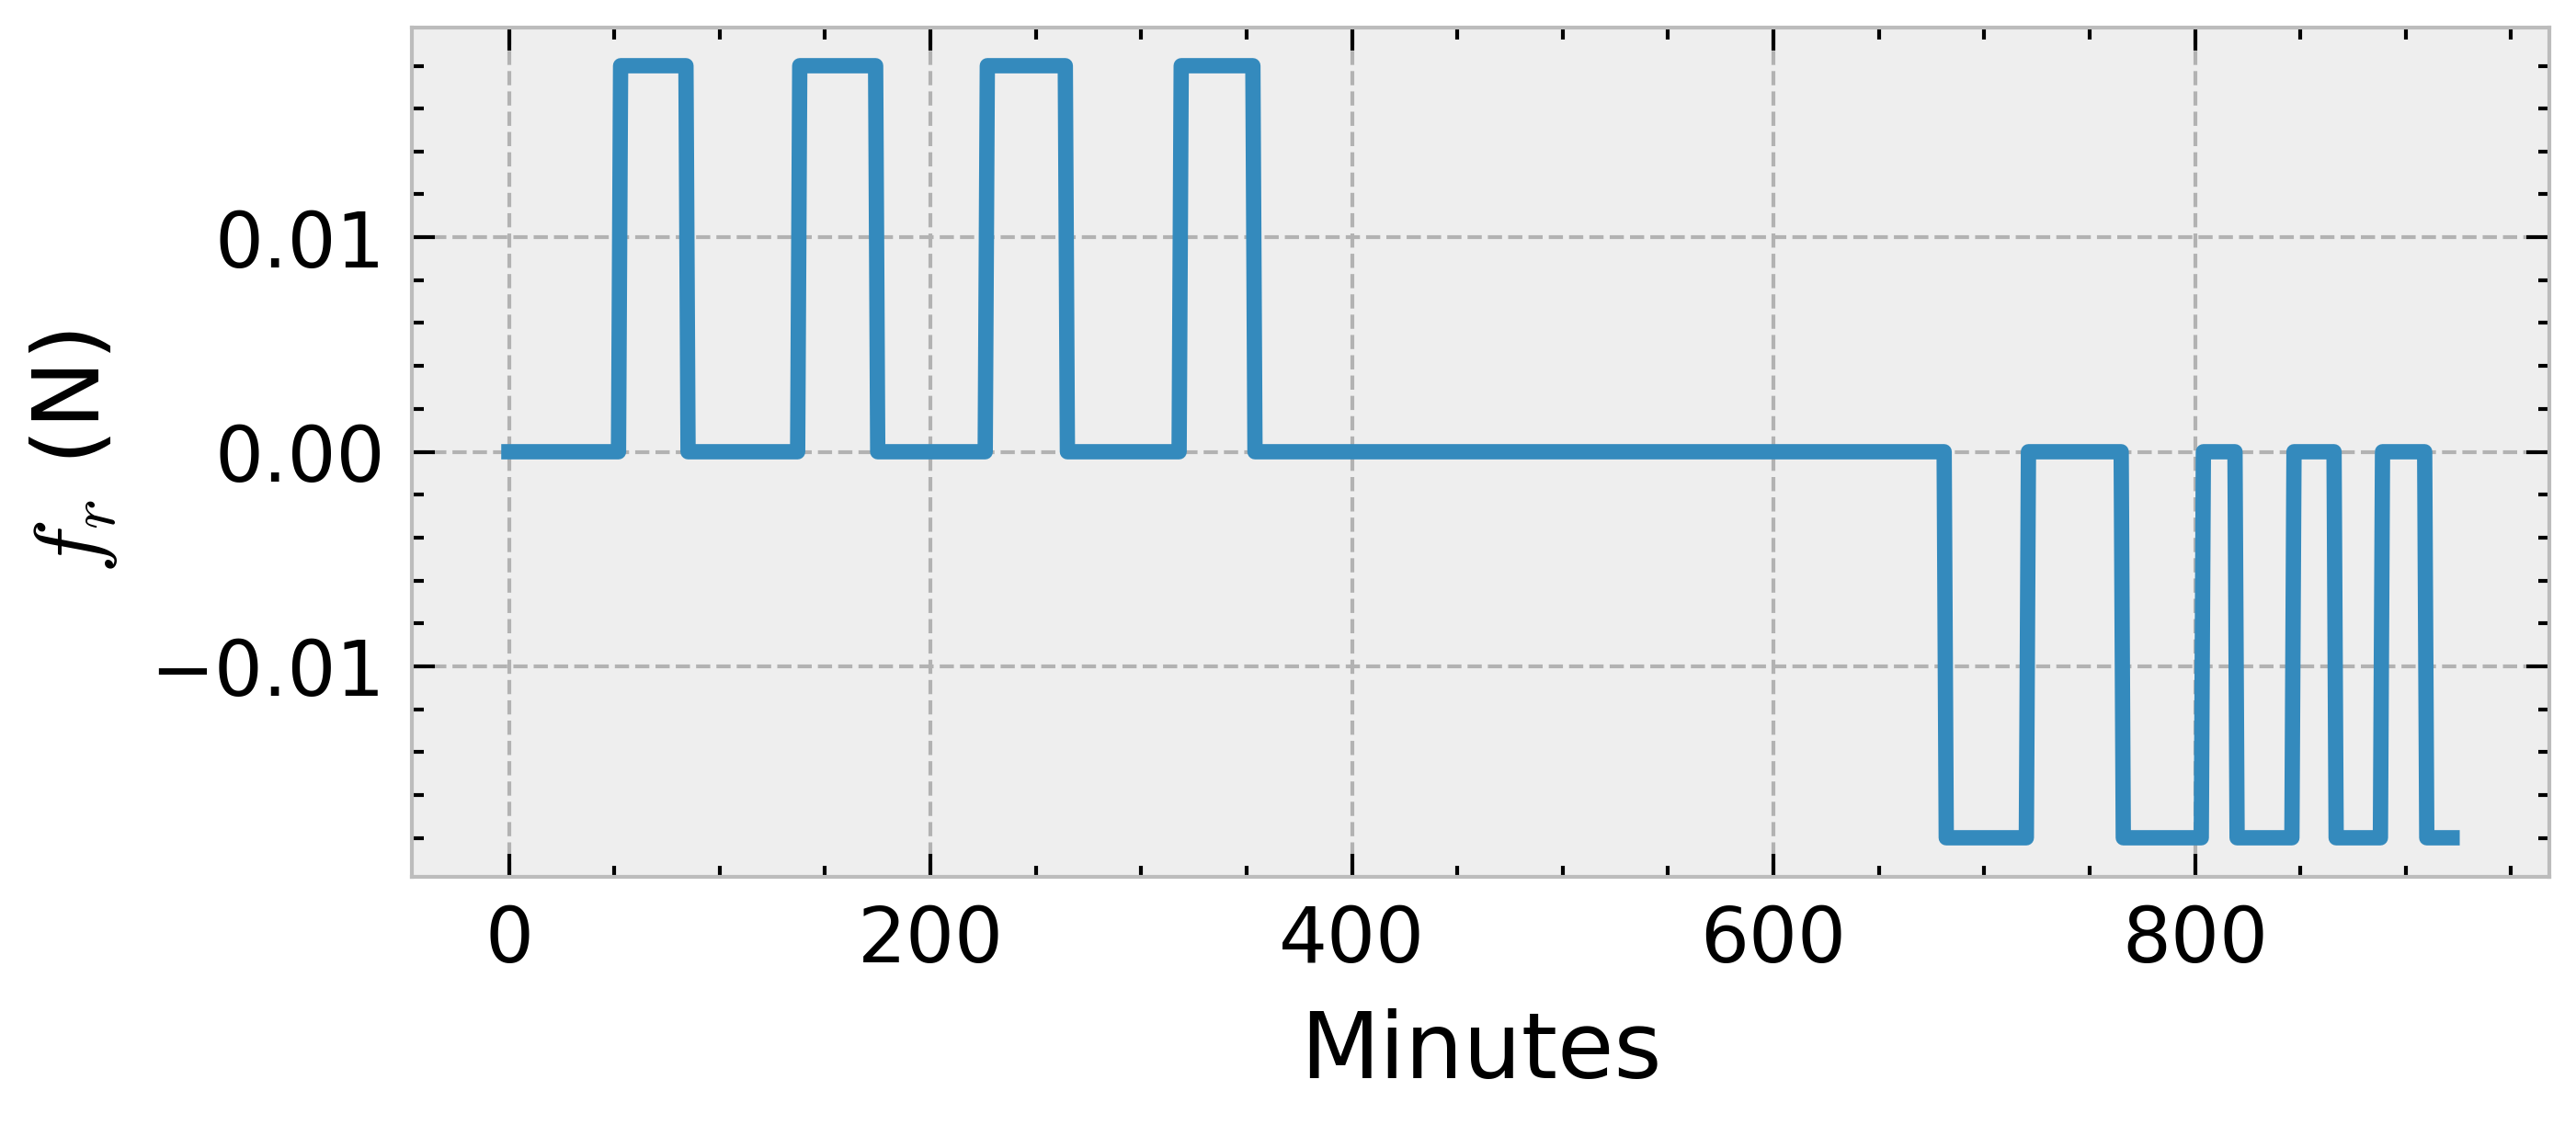

/home/nektaf/workspace_optacom/libs/leo_gym/src/leo_gym/gyms/cam_gym.py:512: RuntimeWarning:

divide by zero encountered in log10



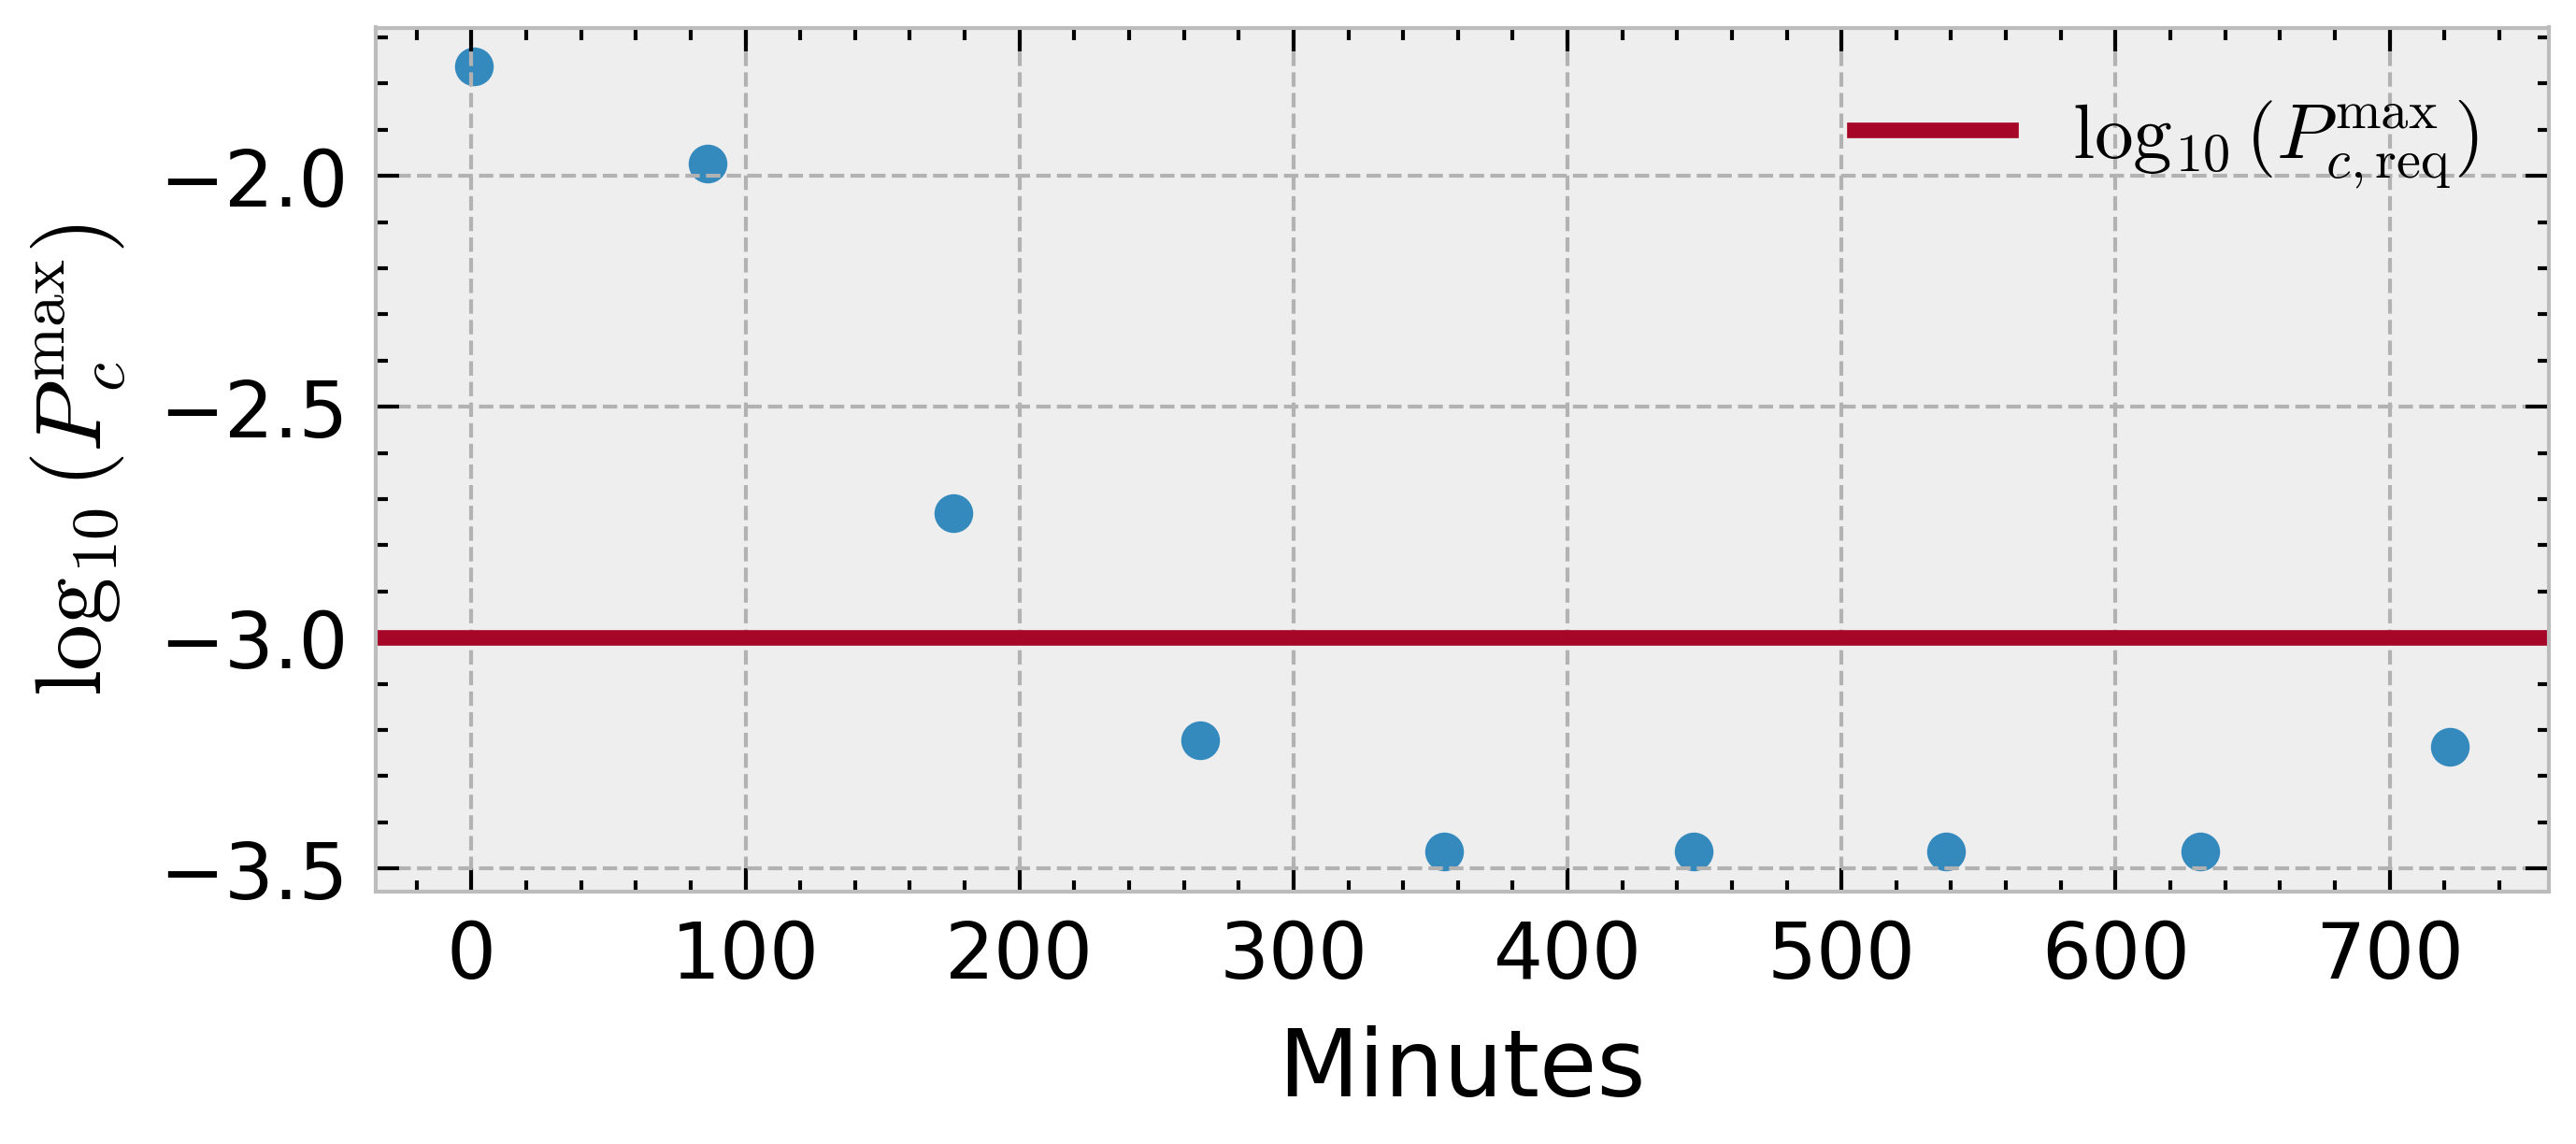

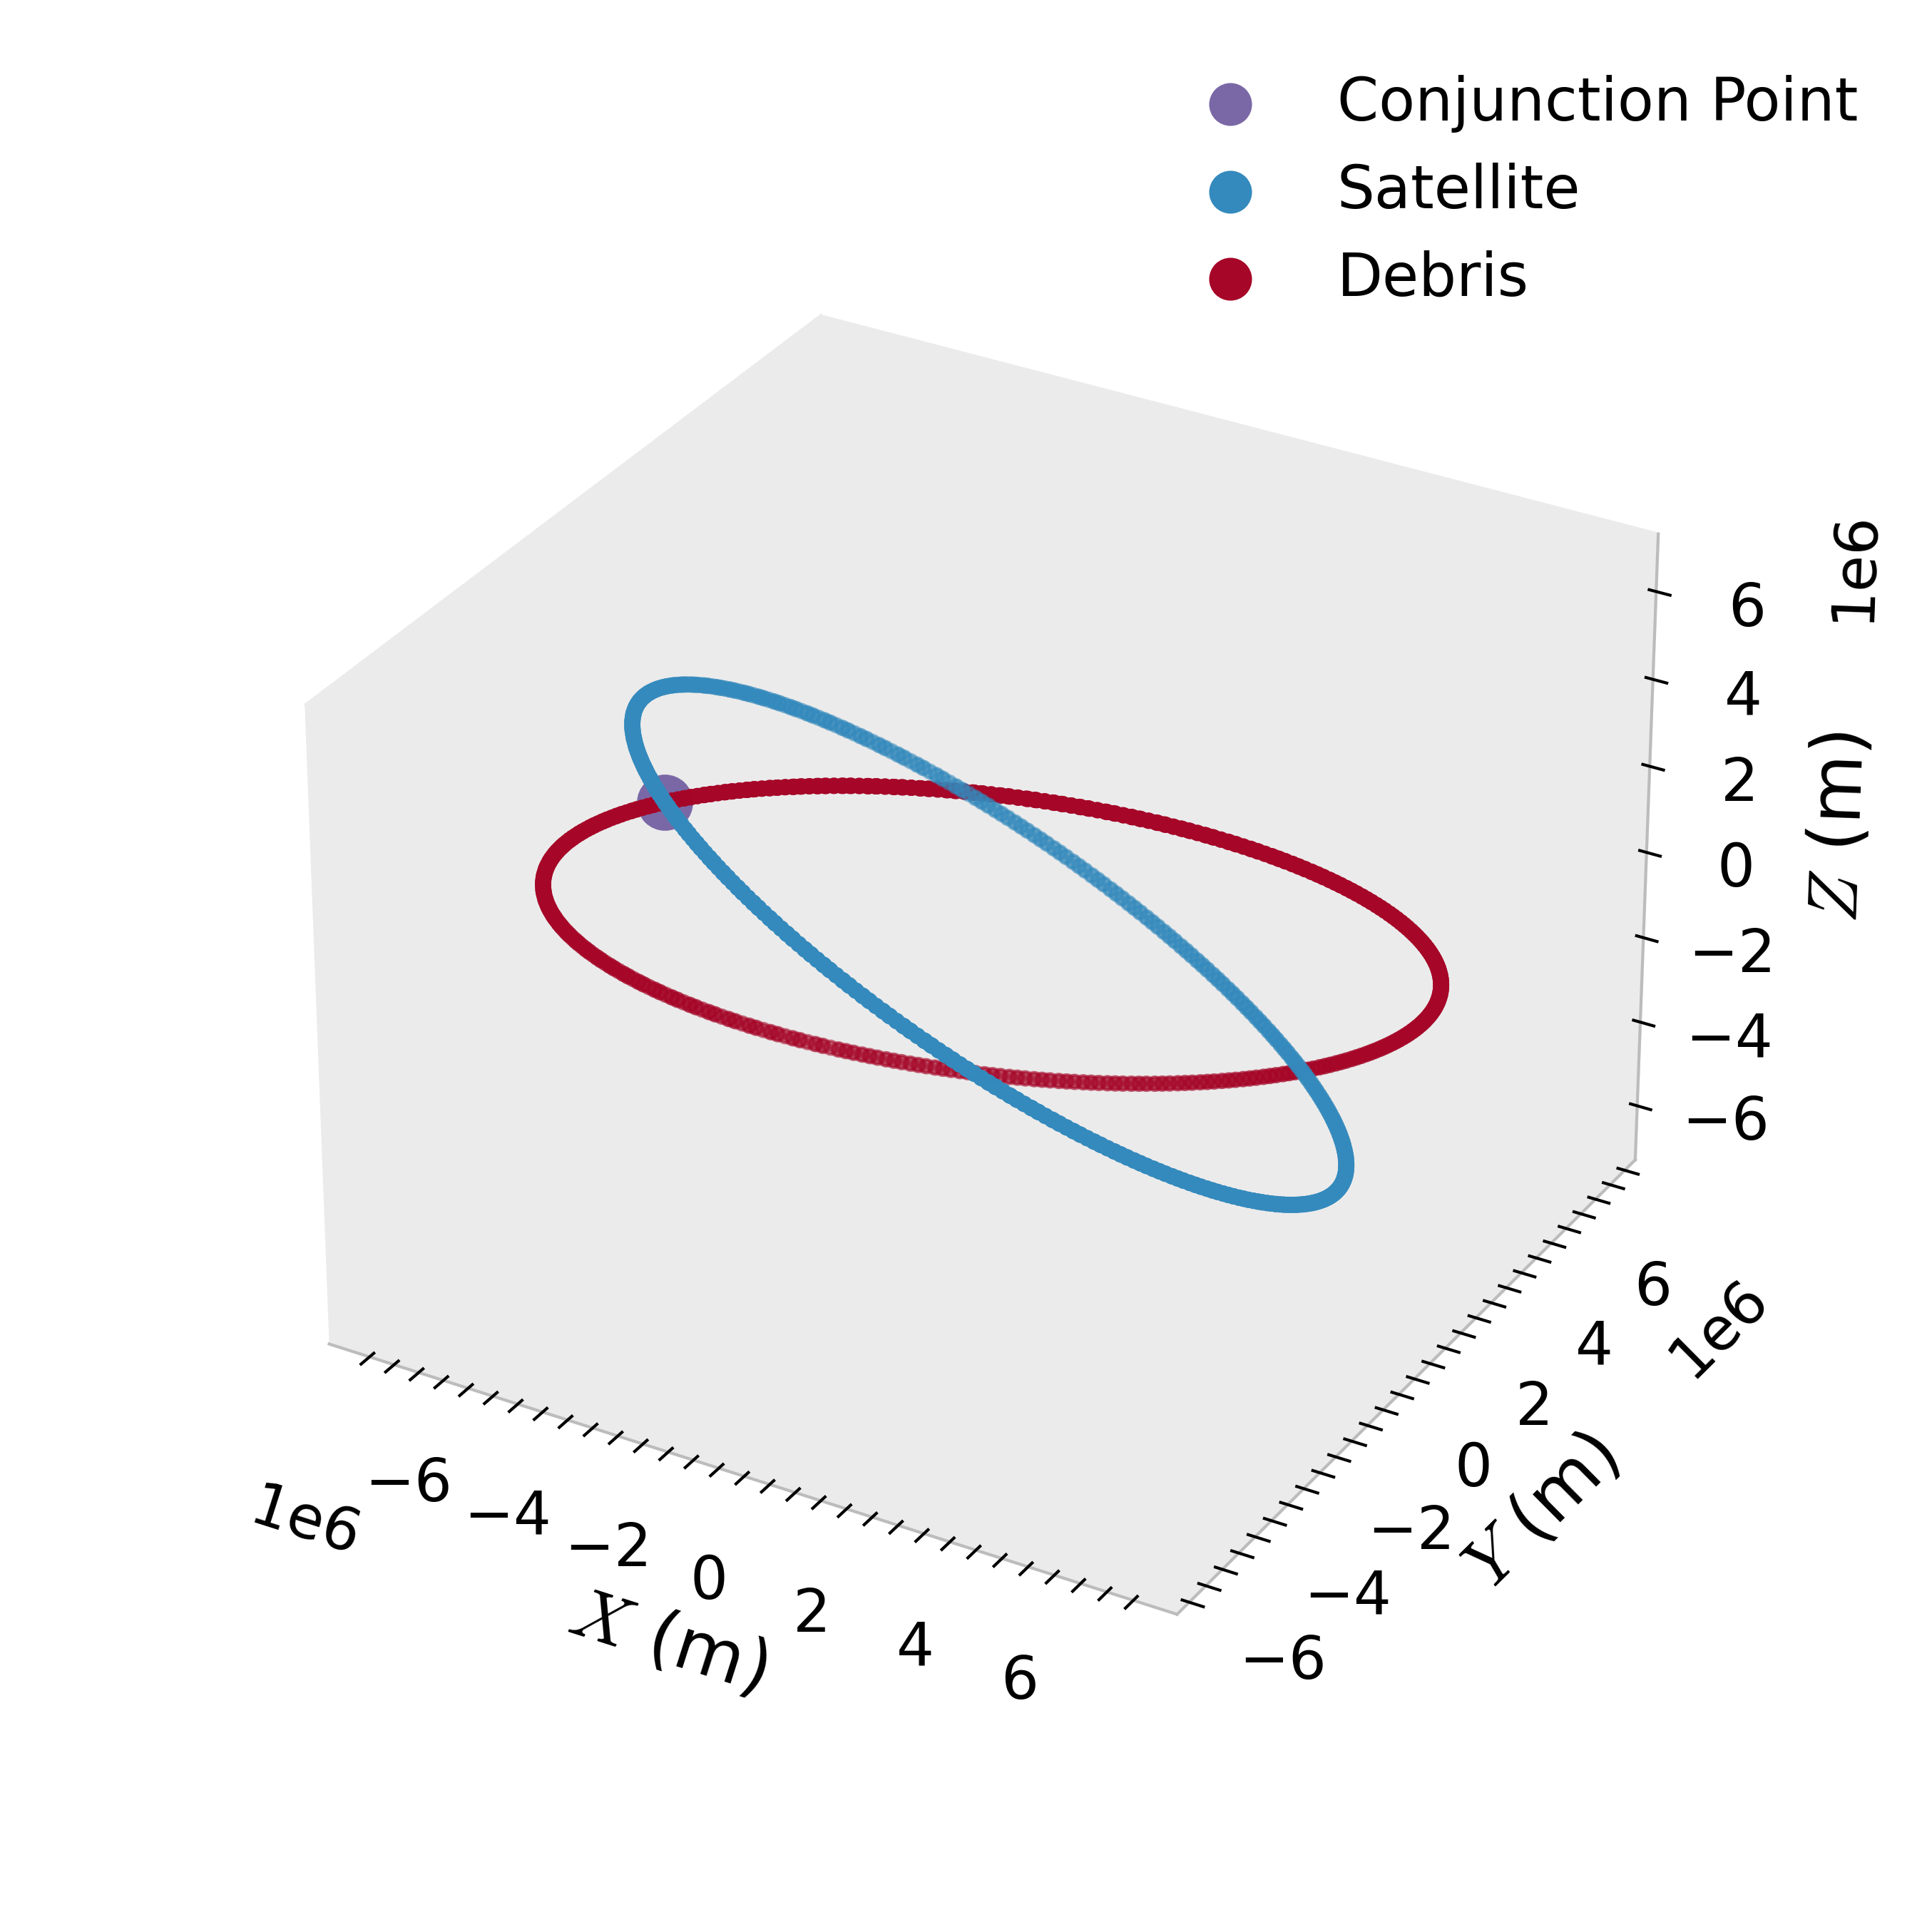

In [ ]:
# %matplotlib widget
env.publication_ready_plots(save_path=os.getcwd())

In [ ]:
# os.makedirs("temp", exist_ok=True)
# path = create_dir(parent_name="temp/test_run")
# path = os.path.abspath(path)
# os.chdir(path)

# DebrisSwarm_1.save_states(path=path)

# config=[config_path,actor_file_path,critic_file_path,SEED]

# with open('config_paths.txt', 'w') as f:
#     for path in config:
#         f.write(f"{path}\n")


In [ ]:
print(os.getcwd())

/home/nektaf/workspace_optacom/libs/leo_gym/notebooks/C3_Collision_Avoidance_Maneuvers_SMDP
